# **Kernel PCA on Billionaires Dataset**
Understand the principal components that explain variation in actual wealth, not ranking.

We will:

Use Rank as target

Apply PCA and Kernel PCA

Compare predictive power

Interpret economic meaning

In [4]:
#import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# Set style
plt.style.use('default')
sns.set_palette("husl")

In [3]:
#load data :
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/billionaires.csv"

df = pd.read_csv(url, index_col="Unnamed: 0")

df.head()

,rank,name,networth,age,country,source,industry
0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments


In [5]:
#Data overview :
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())


Shape: (2600, 7)

Columns: ['rank', 'name', 'networth', 'age', 'country', 'source', 'industry']

First few rows:
   rank                       name networth  age        country  \
0     1                 Elon Musk    $219 B   50  United States   
1     2                Jeff Bezos    $171 B   58  United States   
2     3  Bernard Arnault & family    $158 B   73         France   
3     4                Bill Gates    $129 B   66  United States   
4     5            Warren Buffett    $118 B   91  United States   

               source                industry  
0       Tesla, SpaceX             Automotive   
1              Amazon             Technology   
2                LVMH       Fashion & Retail   
3           Microsoft             Technology   
4  Berkshire Hathaway  Finance & Investments   


Target: y = 1/rank
Range: [0.000388, 1.000000]
Mean: 0.003268, Std: 0.024948


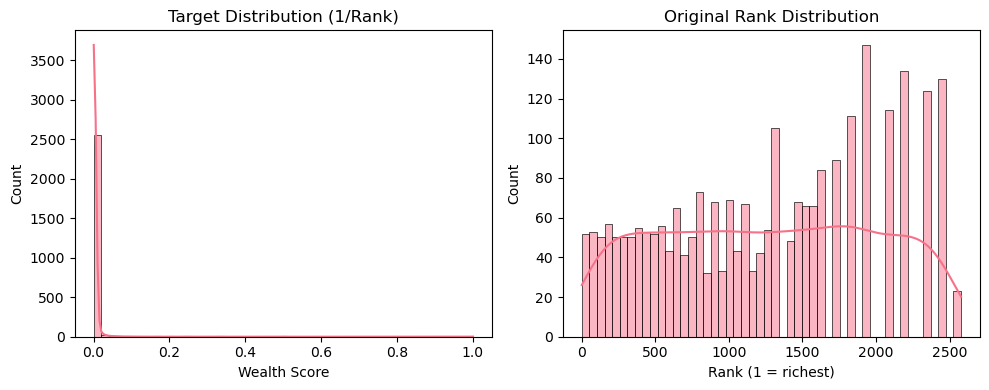

In [6]:
#create target variable :

# Use inverse rank so higher value = richer
df['rank'] = pd.to_numeric(df['rank'], errors='coerce')
y = 1.0 / df['rank']

print(f"Target: y = 1/rank")
print(f"Range: [{y.min():.6f}, {y.max():.6f}]")
print(f"Mean: {y.mean():.6f}, Std: {y.std():.6f}")

# Visualize target
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True)
plt.title("Target Distribution (1/Rank)")
plt.xlabel("Wealth Score")

plt.subplot(1, 2, 2)
sns.histplot(df['rank'], bins=50, kde=True)
plt.title("Original Rank Distribution")
plt.xlabel("Rank (1 = richest)")

plt.tight_layout()
plt.show()

In [7]:
# Drop target related : 
drop_cols = [
    "name",              # ID
    "rank",              # Now our target
    "networth",          # String version
    # Add any intermediate columns if they exist
]

# Only drop columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]
print(f"Dropping: {drop_cols}")

df_model = df.drop(columns=drop_cols)
print(f"\nRemaining columns: {df_model.columns.tolist()}")
print(f"\nData types:\n{df_model.dtypes}")


Dropping: ['name', 'rank', 'networth']

Remaining columns: ['age', 'country', 'source', 'industry']

Data types:
age          int64
country     object
source      object
industry    object
dtype: object


In [8]:
# identify categorical columns
# Auto-detect categorical columns (object dtype)
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns detected: {categorical_cols}")


Categorical columns detected: ['country', 'source', 'industry']


In [9]:
# One hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"  # Keep numeric columns as-is
)

X_processed = preprocessor.fit_transform(df_model)
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame for easier handling
X = pd.DataFrame(X_processed, columns=feature_names)

print(f"Feature matrix shape: {X.shape}")
print(f"Sample feature names: {list(X.columns[:5])}")


Feature matrix shape: (2600, 989)
Sample feature names: ['onehot__country_Algeria', 'onehot__country_Argentina', 'onehot__country_Australia', 'onehot__country_Austria', 'onehot__country_Barbados']


In [10]:
# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardized shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Std (should be ~1): {X_scaled.std():.6f}")

Standardized shape: (2600, 989)
Mean (should be ~0): -0.000000
Std (should be ~1): 1.000000


## **Apply linear PCA**

Explained variance by component:
  PC1: 0.0027 (0.27%)
  PC2: 0.0025 (0.25%)
  PC3: 0.0023 (0.23%)
  PC4: 0.0023 (0.23%)
  PC5: 0.0022 (0.22%)
  PC6: 0.0022 (0.22%)
  PC7: 0.0021 (0.21%)
  PC8: 0.0021 (0.21%)
  PC9: 0.0021 (0.21%)
  PC10: 0.0021 (0.21%)
Total variance explained: 0.0227


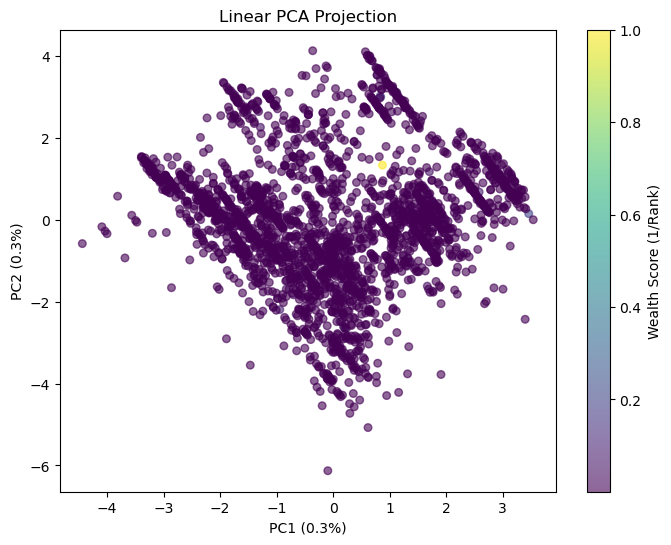

In [11]:
n_components = 10

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Visualize PCA projection
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", alpha=0.6, s=30)
plt.colorbar(sc, label="Wealth Score (1/Rank)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Linear PCA Projection")
plt.show()

## **Apply Kernel PCA**

Kernel PCA complete (gamma=0.01)


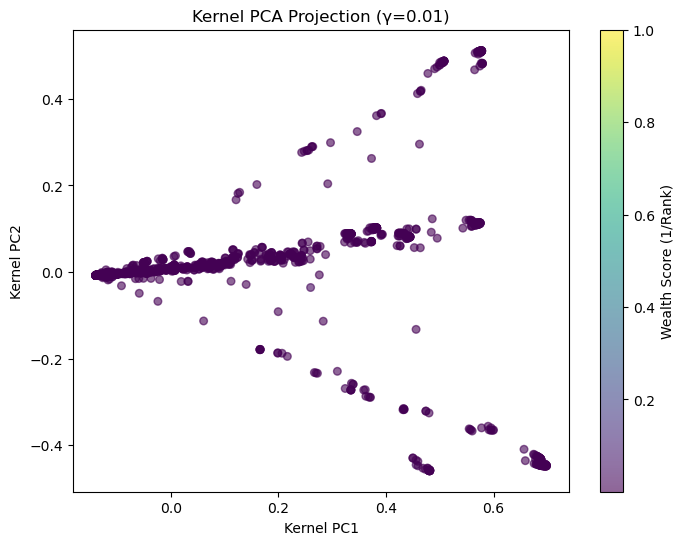

In [12]:
# Try different gamma values
gammas = [0.001, 0.01, 0.1]
best_gamma = 0.01  # Default

kpca = KernelPCA(
    n_components=n_components,
    kernel="rbf",
    gamma=best_gamma,
    fit_inverse_transform=False,
    alpha=0.1
)

X_kpca = kpca.fit_transform(X_scaled)
print(f"Kernel PCA complete (gamma={best_gamma})")

# Visualize Kernel PCA projection
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap="viridis", alpha=0.6, s=30)
plt.colorbar(sc, label="Wealth Score (1/Rank)")
plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.title(f"Kernel PCA Projection (γ={best_gamma})")
plt.show()


In [19]:
#Regresssion COmparison
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Linear PCA + Ridge
model_pca = Ridge(alpha=10.0)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)

r2_pca = r2_score(y_test, y_pred_pca)
mae_pca = mean_absolute_error(y_test, y_pred_pca)

print(f"\nLinear PCA:")
print(f"  R²: {r2_pca:.4f}")
print(f"  MAE: {mae_pca:.6f}")

# Kernel PCA + Ridge
X_train_kpca, X_test_kpca, _, _ = train_test_split(
    X_kpca, y, test_size=0.3, random_state=42
)

model_kpca = Ridge(alpha=10.0)
model_kpca.fit(X_train_kpca, y_train)
y_pred_kpca = model_kpca.predict(X_test_kpca)

r2_kpca = r2_score(y_test, y_pred_kpca)
mae_kpca = mean_absolute_error(y_test, y_pred_kpca)

print(f"\nKernel PCA:")
print(f"  R²: {r2_kpca:.4f}")
print(f"  MAE: {mae_kpca:.6f}")





Linear PCA:
  R²: -0.8806
  MAE: 0.003768

Kernel PCA:
  R²: -0.3140
  MAE: 0.003158


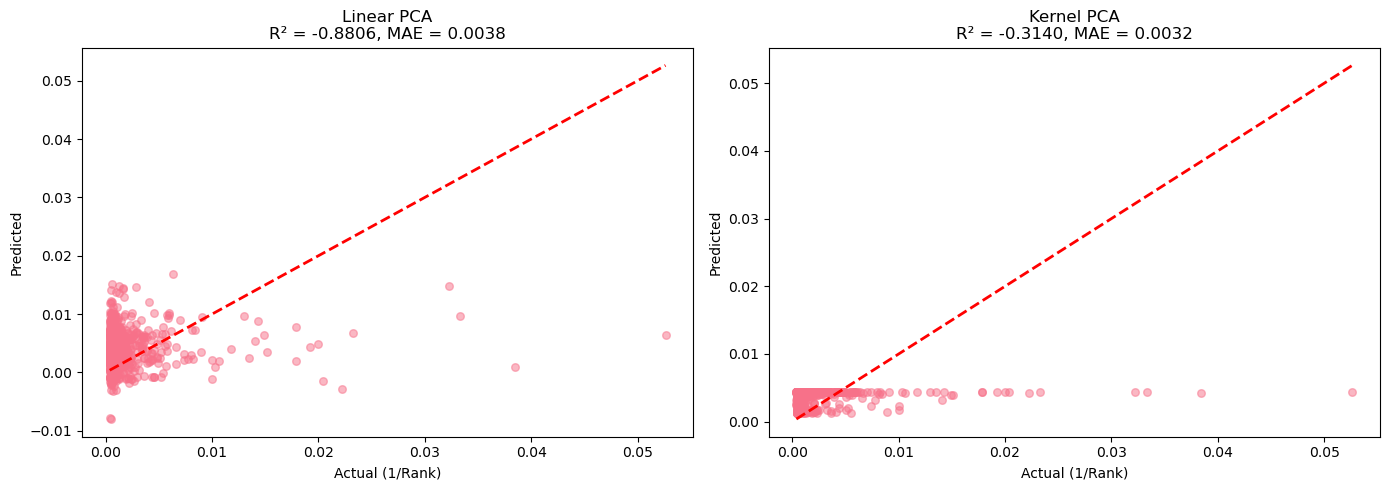

In [21]:
# visualize predictions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- Linear PCA predictions -----
axes[0].scatter(y_test, y_pred_pca, alpha=0.5, s=30)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)
axes[0].set_xlabel("Actual (1/Rank)")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Linear PCA\nR² = {r2_pca:.4f}, MAE = {mae_pca:.4f}")

# ----- Kernel PCA predictions -----
axes[1].scatter(y_test, y_pred_kpca, alpha=0.5, s=30)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)
axes[1].set_xlabel("Actual (1/Rank)")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Kernel PCA\nR² = {r2_kpca:.4f}, MAE = {mae_kpca:.4f}")

plt.tight_layout()
plt.show()

## **Conclusion**

In [22]:
print(f"Linear PCA  → R²: {r2_pca:.4f}")
print(f"Kernel PCA  → R²: {r2_kpca:.4f}")
print(f"Winner: {'Kernel PCA' if r2_kpca > r2_pca else 'Linear PCA'}")

if max(r2_pca, r2_kpca) < 0.1:
    print("\n Both models perform poorly. Possible reasons:")
    print("   - Features don't predict rank well")
    print("   - Need more data or better features")
    print("   - Try classification (top 50 vs rest) instead")

Linear PCA  → R²: -0.8806
Kernel PCA  → R²: -0.3140
Winner: Kernel PCA

 Both models perform poorly. Possible reasons:
   - Features don't predict rank well
   - Need more data or better features
   - Try classification (top 50 vs rest) instead
